# Regressão Logística #

A **regressão logística** (também chamada de regressão logit) é um método estatístico e de aprendizado de máquina supervisionado fundamental para **problemas de classificação**, sendo comumente utilizada para estimar a probabilidade de uma instância pertencer a uma classe específica (**ex:** qual a probabilidade de um e-mail ser spam?).



### 1. O que é Regressão Logística? ### 

Diferente da regressão linear, que prevê valores contínuos, a regressão logística prevê a **probabilidade** de um evento ocorrer, situando o resultado no intervalo entre **0 e 1**. Se a probabilidade estimada for maior ou igual a 50%, o modelo classifica a instância na classe positiva ("1"); caso contrário, na classe negativa ("0").

- **Por que o nome "Regressão"?:** Embora seja um classificador, ela utiliza a lógica da regressão linear para calcular uma soma ponderada dos atributos de entrada (mais um termo de viés/bias) e, em seguida, aplica uma transformação para converter esse valor em probabilidade.

- **Função Logística (Sigmoide):** É a "mágica" por trás do modelo. Ela possui um formato de "S" e sua fórmula matemática é: 
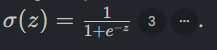



### 2. Pressupostos e Comportamento do Modelo? ### 

Para que o modelo funcione corretamente e seja interpretável, considere os seguintes pontos técnicos: 

- **Linearidade no Logit:** O modelo assume uma relação linear entre os atributos de entrada e o logaritmo das **chances (log-odds)** da classe positiva.

- **Independência das Observações:** Assim como na maioria dos modelos lineares, assume-se que as instâncias de treinamento são independentes entre si. 

- **Sensibilidade a Outliers:** A regressão logística pode ser influenciada por valores atípicos, que distorcem os coeficientes (betas).

- **Interpretação dos Betas:** Os coeficientes *(β)* indicam como as **chances (odds)** mudam com uma unidade de alteração no atributo. Especificamente, *$e^β$* representa o fator de mudança na razão de chances.



### 3. Treinamento e Função de Custo ### 

Diferente da regressão linear, não existe uma "Equação Normal" (forma fechada) para encontrar os melhores parâmetros da logística.

- **Log Loss (Entropia Cruzada):** É a função de custo utilizada. Ela penaliza severamente o modelo se ele estimar uma probabilidade baixa para uma instância positiva ou uma probabilidade alta para uma negativa.

- **Otimização:** O ajuste dos parâmetros feito via Gradiente Descedente (Batch, Estocástico ou Mini-batch), que busca iterativamente os coeficientes que maximizam a verossimilhança dos dados observados. 



### 4. Métricas de Avaliação para Classificação ###

Como o objetivo é classificar, métricas como o *$R^2$* não se aplicam. Utilizamos ferramentas focadas na *matriz de confusão*:

- **Acurácia:** Proporção de acertos totais sobre o total de casos.

- **Precision (Precisão):** De todas as previsões positivas, quantas estão corretas? É vital quando o custo do Falso Positivo é alto.

- **Recall (Revocação):** De todos os casos positivos reais, quantos o modelo encontrou? É prioritário quando deixar passar um positivo é perigoso (ex: detecção de doenças ou fraudes).

- **F1-Score:** Média harmônica entre Precisão e Recall, ideal para comparar modelos em dados desbalanceados.

- **Curva ROC e AUC:** Medem a capacidade do modelo de distinguir entre as classes. A AUC varia de 0,5 (aleatório) a 1,0 (perfeito).

- **Estatística KS:** Mede a distância máxima entre as distribuições acumuladas de positivos e negativos, validando o poder de separação do modelo.



### 5. Tópicos Avançados ###

- **Regularização:** Para evitar o **overfitting**, aplicamos penalidades **L1 (Lasso) ou L2 (Ridge)** aos pesos. O Scikit-Learn aplica L2 por padrão, controlada pelo hiperparâmetro *C* (inverso da força de regularização).

- **Multiclasse:** O modelo pode ser estendido para mais de duas classes através da técnica **One-vs-Rest (OvR) ou pela Regressão Softmax** (também conhecida como logística multinomial).



### Dica da Professora ###

Se os seus dados estiverem muito desbalanceados (ex: 1% de fraude), a curva ROC pode ser enganosa. Nesses casos, prefira a Curva Precision-Recall para uma avaliação mais honesta.

# Entregável obrigatório #

Escolher um problema de classificação binária (ex.: churn, default) e escrever perguntas de negócio que a logística ajudaria a responder.

**Resposta:**

Ao aplicar uma **regressão logística**, é possível formular as perguntas de negócio:

**Probabilidade de churn por perfil de cliente**

- Qual a chance de um cliente com contrato mensal cancelar em comparação com um cliente com contrato anual?
- Clientes que usam serviços adicionais (internet, streaming, telefone) têm menor probabilidade de churn?

**Impacto de variáveis demográficas e de uso**

- Clientes mais jovens ou mais velhos têm maior risco de churn?
- O tempo de permanência (tenure) reduz significativamente a probabilidade de cancelamento?

**Efeito de preços e planos**

- O valor da fatura mensal influencia diretamente na probabilidade de churn?
- Planos com desconto ou fidelização reduzem o risco de saída?

**Detecção de segmentos críticos**

- Quais combinações de fatores (ex.: contrato mensal + alta fatura + sem serviços adicionais) aumentam drasticamente a chance de churn?
- Existe um perfil de cliente “em risco” que deve receber campanhas de retenção?

**Previsão individual**

- Qual a probabilidade de churn para um cliente específico, dado seu histórico e características?
- Podemos priorizar clientes com maior risco para ações de retenção?

# Entregável avançado #

Em Python: treinar uma **logística** com sklearn, mostrar coeficientes (em odds ou log-odds) e explicar o sinal e magnitude de pelo menos 3 deles.

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [38]:
# Carregar dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [40]:
# Remover colunas irrelevantes

df = df.drop(["customerID"],axis=1)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [42]:
# Converter variáveis categóricas para numéricas

for col in df.select_dtypes(include=[object]).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int32  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     7043 non-null   int32  
 7   InternetService   7043 non-null   int32  
 8   OnlineSecurity    7043 non-null   int32  
 9   OnlineBackup      7043 non-null   int32  
 10  DeviceProtection  7043 non-null   int32  
 11  TechSupport       7043 non-null   int32  
 12  StreamingTV       7043 non-null   int32  
 13  StreamingMovies   7043 non-null   int32  
 14  Contract          7043 non-null   int32  
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   int32  


In [44]:
# Separar variáveis independentes e alvo

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [45]:
# Padronização

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
# Treinar regressão logística

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

LogisticRegression(max_iter=1000)

In [47]:
# Coeficientes

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Log-Odds": model.coef_[0],
    "Odds Ratio": [round(np.exp(c), 3) for c in model.coef_[0]]
})

print(coef_df.sort_values(by="Log-Odds", ascending=False).head(10))

             Feature  Log-Odds  Odds Ratio
17    MonthlyCharges  0.830576       2.295
7    InternetService  0.190150       1.209
15  PaperlessBilling  0.172593       1.188
18      TotalCharges  0.113754       1.120
1      SeniorCitizen  0.089224       1.093
6      MultipleLines  0.083949       1.088
16     PaymentMethod  0.060986       1.063
13   StreamingMovies  0.012046       1.012
12       StreamingTV  0.007354       1.007
2            Partner  0.006872       1.007


**Resposta:** 

**Em resumo:** o sinal do coeficiente mostra a direção do efeito (positivo = aumenta churn, negativo = reduz churn), e a magnitude (odds ratio) mostra a intensidade desse efeito em termos de multiplicação das chances.

**O Modelo**
Foi treinado um modelo de **regressão logística** para prever **churn (cancelamento)** dos clientes da Telco.

- A variável alvo é binária: **Churn = 1 (cancelou) ou Churn = 0 (permaneceu).**
- Os coeficientes da regressão logística indicam como cada variável influencia a **chance de churn**, em termos de log-odds e odds ratio.

**Interpretação de 3 Coeficientes**

1. **MontlyCharges (Log-Odds = 0.83, Odds Ratio = 2.30)**

- **Interpretação:** Cada aumento unitário na cobrança mensal **aumenta em 2,3 vezes a chance de churn.**
- **Em termos práticos:** Clientes com faturas mais altas são muitos mais propensos a cancelar.
- **Insight de negócios:** Planos caros precisam ser acompanhados de benefícios claros ou descontos para reduzir o risco.

2. **PaperlessBilling (Log-Odds = 0.17, Odds Ratio = 1.19)**

- **Interpretação:** Clientes com cobrança eletrônica têm **19% mais chance de churn** do que os que recebem fatura física.
- **Em termos práticos:** Perfis digitais parecem mais voláteis, talvez porque comparam preços e serviços com mais facilidade.
- **Insight de negócios:** Campanhas de retenção específicas para clientes digitais podem ser eficazes.

3. **SeniorCitizen (Log-Odds = 0.09, Odds Ratio = 1.09)**

- **Interpretação:** Ser idoso aumenta em ~9% a chance de churn.
- **Em termos práticos:** Embora o efeito seja pequeno, pode indicar que esse grupo percebe menos valor ou enfrenta barreiras de uso.
- **Insight de negócios:** Oferecer planos simplificados ou suporte personalizado pode ajudar a reduzir cancelamentos nesse segmento.

**Limitações Importantes do Modelo**

A regressão logística **assume linearidade na relação entre variáveis independentes e log-odds do churn.**

- Isso significa que ela não captura bem **interações complexas ou relações não lineares** (ex.: efeito combinado de preço alto + contrato mensal + baixa fidelidade).
- Em contextos reais, isso pode levar a **subestimação ou superestimação** do risco de churn.
- Modelos mais flexíveis (como árvores de decisão ou random forest) podem complementar a análise.